In [99]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
#uploading the datasets
details = pd.read_csv('Customer_master.csv')
details.head(5)

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [101]:
#decription of the highest gender
details['gender'].dropna().describe()

count      25000
unique         3
top       Female
freq       12048
Name: gender, dtype: object

In [102]:
details['customer_segment'].value_counts()

customer_segment
Consumer    13638
Premium      6301
VIP          2542
Business     2519
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

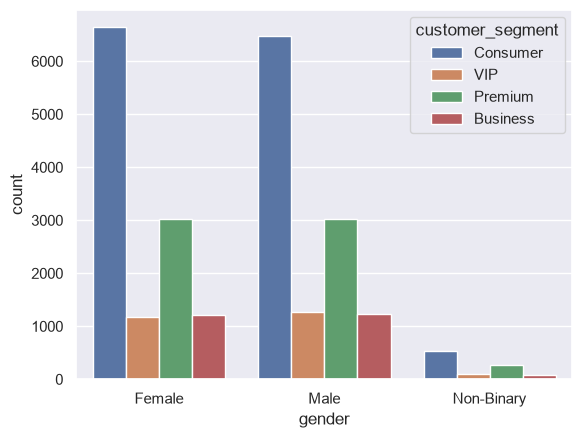

In [103]:
# Showing the number of Males, Females and Non-binary gender that go for Consumer, VIP, Premium and Business treatments
sns.set_theme(style = 'darkgrid')
sns.countplot(details, x = 'gender', hue = 'customer_segment')

<Axes: xlabel='customer_country'>

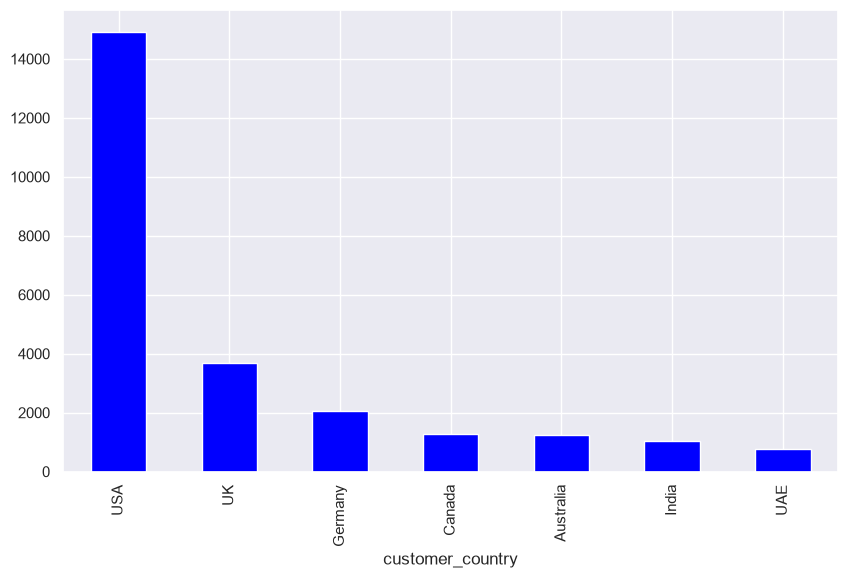

In [104]:
# Graph showing where our customers are situated in

plt.figure(figsize= (10,6))
details.customer_country.value_counts().plot(kind = 'bar', color = 'blue')

In [105]:
# creatung a new column that contains if a certain age group is  for the product or not
def titanics(bank):
    customer_age = bank['customer_age']
    
    if customer_age >= 65: return 'Elders' 
    elif customer_age >= 36: return 'Adults'
    elif customer_age>=18: return 'Young Adults' 
    else: 'Minors'
details['new'] = details.apply(titanics,axis=1)

In [106]:
# counting the number of adult customers (from 36-64)
# elderlies (from 65 - infinite)
# youths (18-34)
details.value_counts('new')

new
Adults          12722
Young Adults     7935
Elders           4343
Name: count, dtype: int64

In [107]:
details[0:5]

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost,new
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58,Adults
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45,Adults
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53,Adults
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02,Young Adults
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34,Adults


<Axes: xlabel='new', ylabel='count'>

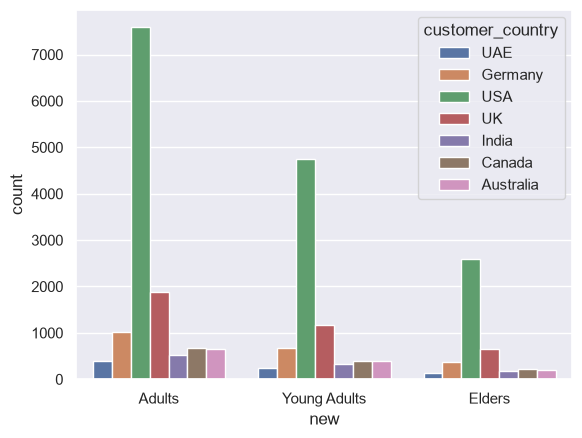

In [108]:
sns.countplot(details, x = 'new', hue = 'customer_country')

<Axes: xlabel='new', ylabel='count'>

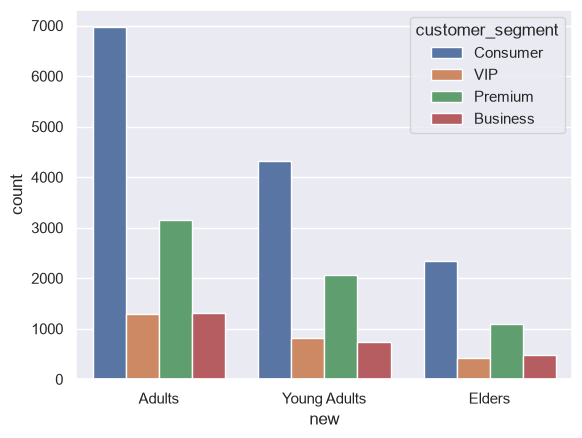

In [109]:
sns.countplot(details, x = 'new', hue = 'customer_segment')

<Axes: xlabel='new', ylabel='count'>

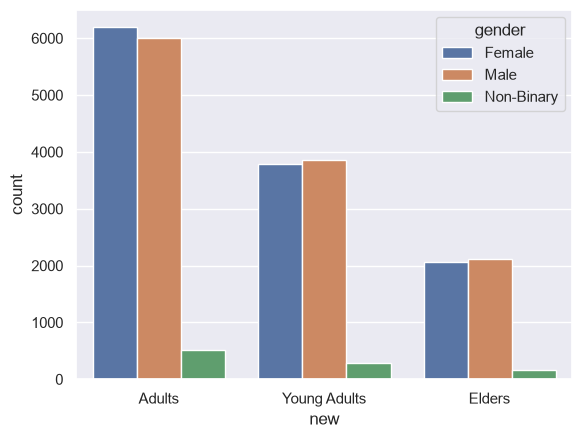

In [110]:
sns.countplot(details, x = 'new', hue = 'gender')

In [111]:
details.value_counts('customer_city')

customer_city
South Michael       30
Lake Michael        30
East Michael        23
Port Michael        21
South James         20
                    ..
Pierceshire          1
Port Roberthaven     1
West Theresaport     1
Kristineport         1
Blankenshipburgh     1
Name: count, Length: 15555, dtype: int64

In [112]:
details.value_counts('region').sum

<bound method Series.sum of region
South      7996
Central    5358
West       4750
East       3874
North      3022
Name: count, dtype: int64>

<Axes: xlabel='customer_country', ylabel='count'>

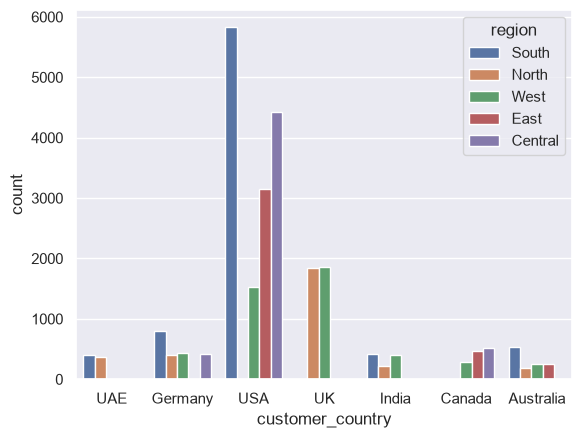

In [113]:
sns.countplot(details, x = 'customer_country', hue ='region')

In [114]:
details[details['customer_country'].isin(['USA', 'UAE', 'Germany', 'UK', 'India', 'Canada', 'Austrailia'])].groupby('customer_country')['customer_acquisition_cost'].sum()

customer_country
Canada      54501.58
Germany     86377.15
India       43546.68
UAE         31992.46
UK         156458.71
USA        628131.77
Name: customer_acquisition_cost, dtype: float64

In [115]:
avg = details.groupby('customer_country')['customer_acquisition_cost'].mean().reset_index()

In [116]:
avg

,customer_country,customer_acquisition_cost
0,Australia,42.972758
1,Canada,42.612651
2,Germany,42.217571
3,India,41.831585
4,UAE,41.280594
5,UK,42.274712
6,USA,42.085881


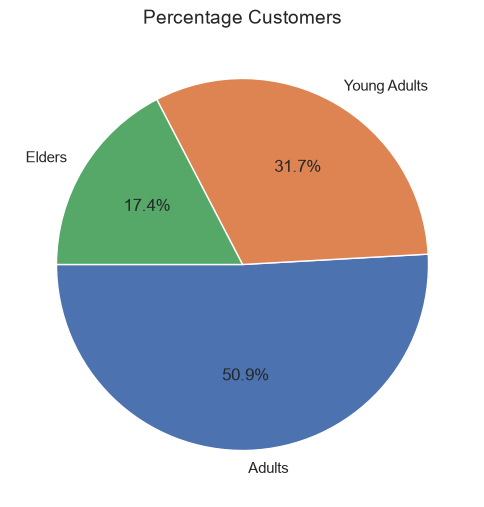

In [138]:
percentage = details['new'].value_counts(normalize = True)*100
plt.figure(figsize = (6,8))
plt.title('Percentage Customers', fontsize = 14)
plt.pie(percentage, labels = percentage.index, autopct = '%1.1f%%', startangle = 180)

In [139]:
percentage

new
Adults          50.888
Young Adults    31.740
Elders          17.372
Name: proportion, dtype: float64